In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import os
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define path to the pre-processed SMARD dataset
file_path = (
    "/content/drive/MyDrive/Colab Notebooks/SMARD_Cleaned_20260806_20260816.csv"
)

# Verify file existence
if os.path.exists(file_path):
  print("Dataset found successfully! Proceeding with data loading...")
else:
  print(
      "File not found! Please verify the folder structure in your Google Drive."
  )

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset found successfully! Proceeding with data loading...


In [21]:
pip install matplotlib pillow numpy

/tmp/ipykernel_1293/3571671861.py:15: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Start'] = pd.to_datetime(df['Start date'])


Advanced animated GIF successfully saved as 'german_bess_market_arbitrage_animated.gif'!


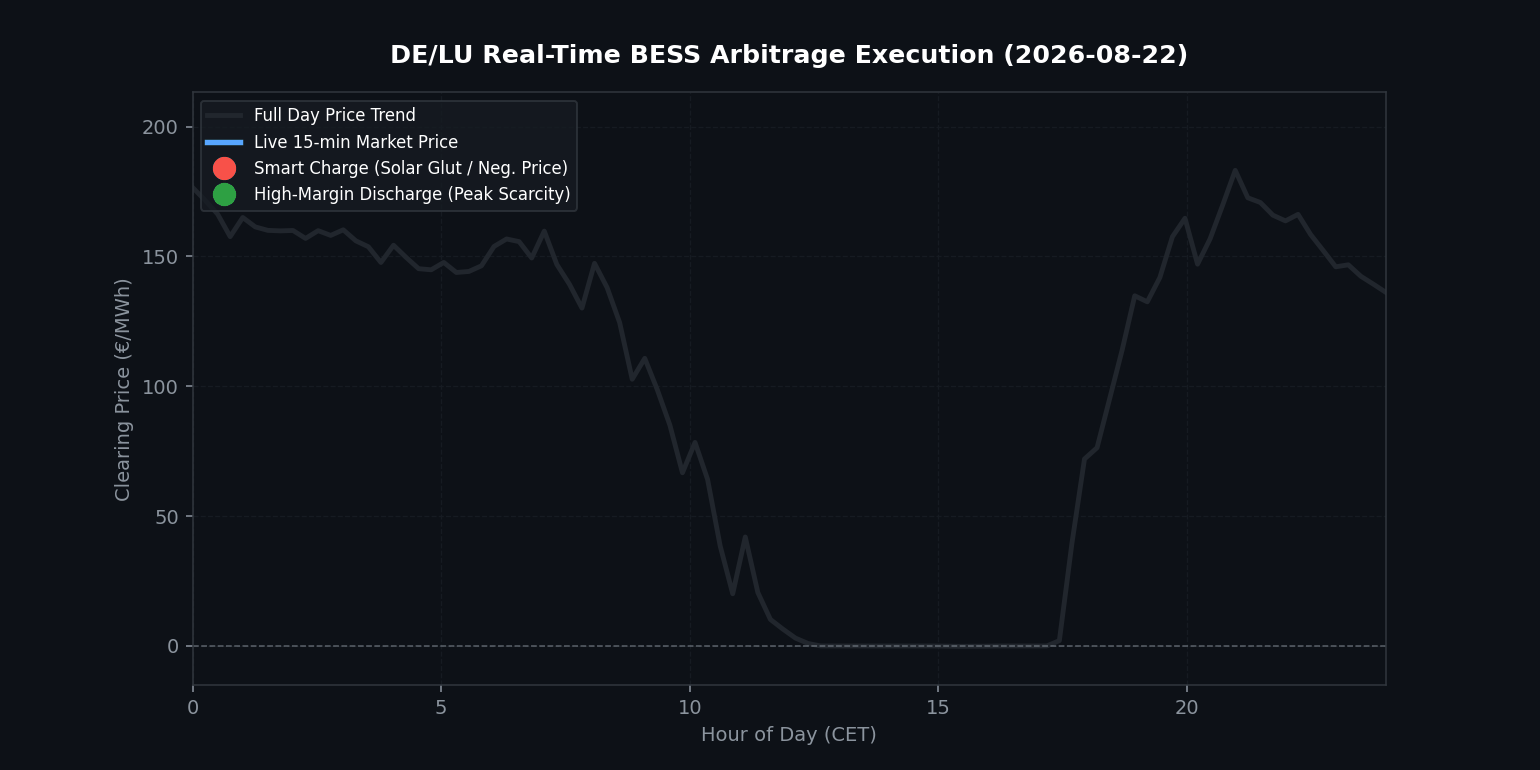

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import Image, display
import os

# Step 1: Locate and load the SMARD dataset
file_path = '/content/drive/MyDrive/Colab Notebooks/Day-ahead_prices_202608180000_202608290000_Quarterhour.csv'
if not os.path.exists(file_path):
    file_path = 'Day-ahead_prices_202608180000_202608290000_Quarterhour.csv'

df = pd.read_csv(file_path, sep=';', encoding='utf-8-sig')
df.columns = [c.strip('"').strip("'") for c in df.columns]
df['Start'] = pd.to_datetime(df['Start date'])
price_col = [c for c in df.columns if 'Germany/Luxembourg' in c][0]
df['Price'] = pd.to_numeric(df[price_col].astype(str).str.replace(',', '.'), errors='coerce')
df['Date'] = df['Start'].dt.date

# Step 2: Extract a volatile target day (Aug 22, 2026 - high renewable penetration & spikes)
target_date = pd.to_datetime('2026-08-22').date()
day_df = df[df['Date'] == target_date].dropna(subset=['Price'])

hours = np.linspace(0, 24, len(day_df))
prices = day_df['Price'].values

# Step 3: Setup professional dark-themed figure layout
fig, ax = plt.subplots(figsize=(11, 5.5), facecolor='#0d1117')
ax.set_facecolor('#0d1117')

# Static background reference profile (dimmed)
ax.plot(hours, prices, color='#21262d', linewidth=2.5, linestyle='-', label='Full Day Price Trend')

# Dynamic animated elements
line, = ax.plot([], [], color='#58a6ff', linewidth=2.8, label='Live 15-min Market Price')
charging_dot, = ax.plot([], [], 'o', color='#f85149', markersize=11, label='Smart Charge (Solar Glut / Neg. Price)')
discharging_dot, = ax.plot([], [], 'o', color='#2ea043', markersize=11, label='High-Margin Discharge (Peak Scarcity)')

# Chart limits and aesthetics
ax.set_xlim(0, 24)
ax.set_ylim(min(prices.min() - 15, -10), prices.max() + 30)
ax.axhline(0, color='#8b949e', linestyle='--', linewidth=0.8, alpha=0.6)

ax.set_title(f"DE/LU Real-Time BESS Arbitrage Execution ({target_date})", color='white', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel("Hour of Day (CET)", color='#8b949e', fontsize=10)
ax.set_ylabel("Clearing Price (€/MWh)", color='#8b949e', fontsize=10)

ax.tick_params(colors='#8b949e', which='both')
for spine in ax.spines.values():
    spine.set_edgecolor('#30363d')

ax.grid(True, color='#161b22', linestyle='--', linewidth=0.7)
ax.legend(loc='upper left', facecolor='#161b22', edgecolor='#30363d', labelcolor='white', fontsize=8.5)

# Step 4: Animation update logic
def init():
    line.set_data([], [])
    charging_dot.set_data([], [])
    discharging_dot.set_data([], [])
    return line, charging_dot, discharging_dot

def update(frame):
    current_idx = frame + 1
    current_hours = hours[:current_idx]
    current_prices = prices[:current_idx]

    line.set_data(current_hours, current_prices)

    h = hours[current_idx - 1]
    p = prices[current_idx - 1]

    # Trigger smart charging during midday solar dip / negative pricing
    if 11 <= h <= 17 and p <= 15:
        charging_dot.set_data([h], [p])
        discharging_dot.set_data([], [])
    # Trigger high-margin discharge during evening scarcity peak
    elif 19 <= h <= 24 and p >= 130:
        discharging_dot.set_data([h], [p])
        charging_dot.set_data([], [])
    else:
        charging_dot.set_data([], [])
        discharging_dot.set_data([], [])

    return line, charging_dot, discharging_dot

# Step 5: Render, save and display GIF
ani = animation.FuncAnimation(fig, update, frames=len(hours), init_func=init, interval=70, blit=True)

gif_filename = 'german_bess_market_arbitrage_animated.gif'
ani.save(gif_filename, writer='pillow', fps=24, dpi=140)
plt.close()

print(f"Advanced animated GIF successfully saved as '{gif_filename}'!")
display(Image(filename=gif_filename))